# transform-replacement-data-2

Updated as of Sept 22. This notebook cleans and de-dupes the replacements data for July 23-July 31 and August 2025. 

Steps:
1. Exclude records with a status that is not "Complete" and do not have a replacement date
3. Clean up addresses: capitalize all, remove periods/commas, replace dashes with spaces
4. Remove duplicate addresses at the same line section, keeping the record with the most recent replacement date if they have different dates
5. Count only records with both completed line sections, both public and private sides.
6. Geocode by 1) matching with Peter's data on substring and 2) census geocoding the rest
7. De-duplicate so there's only one record for each address; for the three addresses that were fully replaced under more than one program, keep their duplicate records.
8. Assign addresses to tracts and community areas

In [1]:
# load packages
import pandas as pd
import csv
import geopandas as gpd
import re
import numpy as np
import censusbatchgeocoder

In [37]:
# import all sheets into a dict with sheet name as key, value as df
sheet_list = ['CIP Sewer Main',
              'CIP Water Main',
              'Breaks Leaks',
              'Homeowner Initiated',
              'Equity',
              'Daycare Private',
              'Daycare Public',
              'Block Level LSLR']

path = '../source/T108293 Responsive Document2.xlsx'

sheet_dict = {}

for sheet in sheet_list:
    df = pd.read_excel(path, sheet_name=sheet)
    print(sheet)
    print(len(df))
    sheet_dict[sheet] = df

CIP Sewer Main
1436
CIP Water Main
2688
Breaks Leaks
17343
Homeowner Initiated
1018
Equity
2051
Daycare Private
525
Daycare Public
518
Block Level LSLR
467


In [38]:
# end of july
# note: i changed the sheet names to Breaks Leaks and Block Level LSLR to match previous data
path = '/Users/aqin/data-journalism/lead-pipes-chi/source/T111792_RecentReplacements-8.27.xlsx'

sheet_dict_j = {} # july

for sheet in sheet_list:
    dfj = pd.read_excel(path, sheet_name=sheet) # dfj = df july
    print(sheet)
    print(len(dfj))
    sheet_dict_j[sheet] = dfj

CIP Sewer Main
966
CIP Water Main
1141
Breaks Leaks
1526
Homeowner Initiated
55
Equity
58
Daycare Private
147
Daycare Public
162
Block Level LSLR
50


In [39]:
# august
# note: i changed the sheet names to Breaks Leaks and Block Level LSLR to match previous data
path = '/Users/aqin/data-journalism/lead-pipes-chi/source/T114037_Responsive_Document.xlsx'

sheet_dict_a = {} # for august

for sheet in sheet_list:
    dfa = pd.read_excel(path, sheet_name=sheet) # dfa = df august
    print(sheet)
    print(len(dfa))
    sheet_dict_a[sheet] = dfa

CIP Sewer Main
478
CIP Water Main
1224
Breaks Leaks
2195
Homeowner Initiated
19
Equity
260
Daycare Private
392
Daycare Public
394
Block Level LSLR
590


In [40]:
# combine all sheets into one df with a col for program
df_list = []

for sheet in sheet_list:
    sheet_dict[sheet]['program'] = sheet
    df_list.append(sheet_dict[sheet])
    
    sheet_dict_j[sheet]['program'] = sheet
    df_list.append(sheet_dict_j[sheet])

    sheet_dict_a[sheet]['program'] = sheet
    df_list.append(sheet_dict_a[sheet])

programs = pd.concat(df_list, ignore_index=True)
print(len(programs)) # should be 9,657 + 26,046 = 35,703
programs

35703


/var/folders/4l/t591xjt528jfczvfrdl8nnz40000gr/T/ipykernel_90918/649625683.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  programs = pd.concat(df_list, ignore_index=True)


,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer
0,CIP SM LSLR,PUBLIC,1015 21 E 82ND ST,Completed,60619,8.0,2024-10-29,CIP Sewer Main,NaN
1,CIP SM LSLR,CONSUMER,1015 21 E 82ND ST,Completed,60619,8.0,2024-10-29,CIP Sewer Main,NaN
2,CIP SM LSLR,PUBLIC,1025 E 82ND ST,Completed,60619,8.0,2024-11-01,CIP Sewer Main,NaN
3,CIP SM LSLR,CONSUMER,1025 E 82ND ST,Completed,60619,8.0,2024-11-01,CIP Sewer Main,NaN
4,CIP SM LSLR,PUBLIC,10864 S OAKLEY AVE,Completed,60643,19.0,2025-03-07,CIP Sewer Main,NaN
...,...,...,...,...,...,...,...,...,...
35698,Block Level LSLR,CONSUMER,8038 S JEFFERY BLVD,In Progress - New Record,60617,8.0,NaT,Block Level LSLR,NaN
35699,Block Level LSLR,CONSUMER,8044 S JEFFERY BLVD,In Progress - New Record,60617,8.0,NaT,Block Level LSLR,NaN
35700,Block Level LSLR,CONSUMER,8046 S JEFFERY BLVD,In Progress - New Record,60617,8.0,NaT,Block Level LSLR,NaN
35701,Block Level LSLR,PUBLIC,8123 S JEFFERY BLVD,In Progress - New Record,60617,8.0,NaT,Block Level LSLR,NaN


In [43]:
# convert date and add new date cols
programs['Date Completed'] = pd.to_datetime(programs['Date Completed'])
programs['completed_year'] = programs['Date Completed'].dt.year
programs['completed_month_year'] = programs['Date Completed'].dt.strftime('%m/%Y')
programs['completed_day'] = programs['Date Completed'].dt.strftime('%m-%d')

In [42]:
# first and last dates completed
print(programs[programs['Status'] == 'Completed'].sort_values('completed_day').head(2))
print(programs[programs['Status'] == 'Completed'].sort_values('completed_day').tail(2))

              LSLR Program Public or Consumer         Work Address     Status  \
19118  Breaks & Leaks LSLR             PUBLIC    4423 N LOWELL AVE  Completed   
19108  Breaks & Leaks LSLR             PUBLIC  12449 S EMERALD AVE  Completed   

         Zip  Ward Date Completed       program BOTH AS REQUIRED or Consumer  \
19118  60630  39.0     2025-01-02  Breaks Leaks                          NaN   
19108  60628   9.0     2025-01-02  Breaks Leaks                          NaN   

       completed_year completed_month_year completed_day  
19118          2025.0              01/2025         01-02  
19108          2025.0              01/2025         01-02  
       LSLR Program  Public or Consumer              Work Address     Status  \
32908  Daycare LSLR  CONSUMER - DAYCARE        7313 N WESTERN AVE  Completed   
32970  Daycare LSLR  CONSUMER - DAYCARE  8910 12 S COMMERCIAL AVE  Completed   

         Zip  Ward Date Completed          program  \
32908  60645  50.0            NaT  Daycare 

In [208]:
programs.to_csv('../processed/replacements_unduplicated_uncleaned.csv', index=False)

In [209]:
programs[programs['Work Address'] == '4323 W Cermak RD']

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day
32733,Daycare LSLR,CONSUMER - DAYCARE,4323 W Cermak RD,Completed,60623,22.0,2024-09-09,Daycare Private,NaN,2024.0,09/2024,09-09
32734,Daycare LSLR,CONSUMER - DAYCARE,4323 W Cermak RD,Completed,60623,22.0,2024-09-09,Daycare Private,NaN,2024.0,09/2024,09-09
33796,Daycare LSLR,PUBLIC,4323 W Cermak RD,Completed,60623,22.0,2024-09-09,Daycare Public,NaN,2024.0,09/2024,09-09
33797,Daycare LSLR,PUBLIC,4323 W Cermak RD,Completed,60623,22.0,2024-09-09,Daycare Public,NaN,2024.0,09/2024,09-09


In [211]:
programs[programs['Work Address'].str.contains('3046')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day
14534,Breaks & Leaks LSLR,PUBLIC,3046 N NAGLE AVE,Completed,60634,36.0,2024-05-13 00:00:00,Breaks Leaks,NaN,2024.0,05/2024,05-13
14535,Breaks & Leaks LSLR,CONSUMER,3046 N NAGLE AVE,Completed,60634,36.0,2024-05-13 00:00:00,Breaks Leaks,NaN,2024.0,05/2024,05-13
19112,Breaks & Leaks LSLR,PUBLIC,3046 W LOGAN BLVD,Completed,60647,1.0,2025-01-02 00:00:00,Breaks Leaks,NaN,2025.0,01/2025,01-02
19113,Breaks & Leaks LSLR,CONSUMER,3046 W LOGAN BLVD,Completed,60647,1.0,2025-01-02 00:00:00,Breaks Leaks,NaN,2025.0,01/2025,01-02
30756,Equity LSLR,BOTH AS REQUIRED,3046 S CHRISTIANA AVE,Completed,60623,22.0,2023-06-30 00:00:00,Equity,NaN,2023.0,06/2023,06-30
30757,Equity LSLR,BOTH AS REQUIRED,3046 W ADDISON ST,Completed,60618,35.0,2024-10-01 00:00:00,Equity,NaN,2024.0,10/2024,10-01
32146,Equity LSLR,NaN,3046 W SHERWIN AVE,Completed,60645,50.0,2025-07-25 15:00:00,Equity,BOTH AS REQUIRED,2025.0,07/2025,07-25
34809,Block Level LSLR,PUBLIC,3046 S LOWE AVE,Completed,60616,11.0,2025-04-07 00:00:00,Block Level LSLR,NaN,2025.0,04/2025,04-07
34810,Block Level LSLR,CONSUMER,3046 S LOWE AVE,Completed,60616,11.0,2025-04-07 00:00:00,Block Level LSLR,NaN,2025.0,04/2025,04-07


In [212]:
programs[programs['Work Address'].str.contains('5202')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day
13260,Breaks & Leaks LSLR,PUBLIC,5202 10 S CORNELL AVE,Completed,60615,5.0,2024-03-11,Breaks Leaks,NaN,2024.0,03/2024,03-11
13261,Breaks & Leaks LSLR,CONSUMER,5202 10 S CORNELL AVE,Completed,60615,5.0,2024-03-11,Breaks Leaks,NaN,2024.0,03/2024,03-11
30033,Homeowner Initiated LSLR,BOTH AS REQUIRED,5202 s. Kimbark,Completed,60615,4.0,2025-07-30,Homeowner Initiated,NaN,2025.0,07/2025,07-30


## 1) Exclude non-complete records

In [44]:
programs.groupby('Status', dropna=False).size()

Status
Cancelled                     137
Completed                   22974
In Progress                 10622
In Progress - New Record     1968
NaN                             2
dtype: int64

In [46]:
step1 = programs[(programs['Status'] == 'Completed') & (programs['Date Completed'].notnull())].copy()

print(len(step1))

22807


Excluded 12,896 records that are not "complete" or have a completed date.

In [47]:
print(len(programs) - len(step1))

12896


## 2) Clean addresses

Capitalize all, remove periods/commas, replace dashes with spaces.

In [98]:
# standardize addresses
def clean_address(address):
    clean_address = address.replace(',','')
    clean_address = clean_address.replace('.','')
    clean_address = clean_address.replace('-',' ')
    clean_address = clean_address.upper()
    
    return clean_address

step2 = step1.copy()

step2['clean_address'] = step2['Work Address'].apply(clean_address)
step2.head()

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address
0,CIP SM LSLR,PUBLIC,1015 21 E 82ND ST,Completed,60619,8.0,2024-10-29,CIP Sewer Main,NaN,2024.0,10/2024,10-29,1015 21 E 82ND ST
1,CIP SM LSLR,CONSUMER,1015 21 E 82ND ST,Completed,60619,8.0,2024-10-29,CIP Sewer Main,NaN,2024.0,10/2024,10-29,1015 21 E 82ND ST
2,CIP SM LSLR,PUBLIC,1025 E 82ND ST,Completed,60619,8.0,2024-11-01,CIP Sewer Main,NaN,2024.0,11/2024,11-01,1025 E 82ND ST
3,CIP SM LSLR,CONSUMER,1025 E 82ND ST,Completed,60619,8.0,2024-11-01,CIP Sewer Main,NaN,2024.0,11/2024,11-01,1025 E 82ND ST
4,CIP SM LSLR,PUBLIC,10864 S OAKLEY AVE,Completed,60643,19.0,2025-03-07,CIP Sewer Main,NaN,2025.0,03/2025,03-07,10864 S OAKLEY AVE


In [99]:
# use only first street number if range
step2['clean_address'] = step2['clean_address'].str.replace(r"^(\d+)\s+\d+\b", r"\1", regex=True)

In [100]:
# spot check
step2[step2['Work Address'].str.contains('2043 n. Humboldt blvd.')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address
30080,Homeowner Initiated LSLR,BOTH AS REQUIRED,2043 n. Humboldt blvd.,Completed,60647,26.0,2025-08-11,Homeowner Initiated,NaN,2025.0,08/2025,08-11,2043 N HUMBOLDT BLVD


In [101]:
step2[step2['Work Address'].str.contains('4745-47 N Beacon St')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address
29735,Homeowner Initiated LSLR,BOTH AS REQUIRED,4745-47 N Beacon St,Completed,60640,46.0,2023-12-21,Homeowner Initiated,NaN,2023.0,12/2023,12-21,4745 N BEACON ST


In [102]:
step2[step2['Work Address'].str.contains('4636 38 N RAVENSWOOD AVE')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address
7308,CIP WM LSLR,PUBLIC,4636 38 N RAVENSWOOD AVE,Completed,60640,47.0,2025-08-27 22:00:00,CIP Water Main,NaN,2025.0,08/2025,08-27,4636 N RAVENSWOOD AVE
7309,CIP WM LSLR,CONSUMER,4636 38 N RAVENSWOOD AVE,Completed,60640,47.0,2025-08-27 22:00:00,CIP Water Main,NaN,2025.0,08/2025,08-27,4636 N RAVENSWOOD AVE


## 3) Remove duplicate addresses at the same line section

Remove duplicates within the same program. If the completed day is the same, keep either, otherwise, keep the record with the most recent completed day. Like this 2659 N WAYNE AVE address...

In [74]:
step2[step2['Work Address'].str.contains('2659 N WAYNE AVE')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address,cleaner_address
483,CIP SM LSLR,PUBLIC,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,CIP Sewer Main,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE
484,CIP SM LSLR,PUBLIC,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,CIP Sewer Main,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE
485,CIP SM LSLR,CONSUMER,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,CIP Sewer Main,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE
486,CIP SM LSLR,CONSUMER,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,CIP Sewer Main,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE
487,CIP SM LSLR,PUBLIC,"2659 N WAYNE AVE, UNIT A",Completed,60614,32.0,2025-03-06,CIP Sewer Main,NaN,2025.0,03/2025,03-06,2659 N WAYNE AVE UNIT A,2659 N WAYNE AVE UNIT A
488,CIP SM LSLR,CONSUMER,"2659 N WAYNE AVE, UNIT A",Completed,60614,32.0,2025-03-06,CIP Sewer Main,NaN,2025.0,03/2025,03-06,2659 N WAYNE AVE UNIT A,2659 N WAYNE AVE UNIT A
489,CIP SM LSLR,PUBLIC,"2659 N WAYNE AVE, UNIT B",Completed,60614,32.0,2025-03-06,CIP Sewer Main,NaN,2025.0,03/2025,03-06,2659 N WAYNE AVE UNIT B,2659 N WAYNE AVE UNIT B
490,CIP SM LSLR,CONSUMER,"2659 N WAYNE AVE, UNIT B",Completed,60614,32.0,2025-03-06,CIP Sewer Main,NaN,2025.0,03/2025,03-06,2659 N WAYNE AVE UNIT B,2659 N WAYNE AVE UNIT B
8346,Breaks & Leaks LSLR,CONSUMER,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,Breaks Leaks,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE
8347,Breaks & Leaks LSLR,CONSUMER,2659 N WAYNE AVE,Completed,60614,32.0,2023-03-13,Breaks Leaks,NaN,2023.0,03/2023,03-13,2659 N WAYNE AVE,2659 N WAYNE AVE


In [103]:
# sort by date completed and drop duplicates that are the same accross public/consumer, address and program
step3 = step2.copy()

step3 = step3.sort_values('Date Completed', ascending=False).drop_duplicates(subset=['clean_address', 'program', 'Public or Consumer'], keep='first')

print(len(step3))
print(len(step2) - len(step3))

22474
333


Removed 333 records. Spot check a few with known duplicates:

In [104]:
step3[step3['Work Address'].str.contains('7032 S EMERALD AVE')]

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address
10445,Breaks & Leaks LSLR,PUBLIC,7032 S EMERALD AVE,Completed,60621,6.0,2023-08-15,Breaks Leaks,NaN,2023.0,08/2023,08-15,7032 S EMERALD AVE
10447,Breaks & Leaks LSLR,CONSUMER,7032 S EMERALD AVE,Completed,60621,6.0,2023-08-15,Breaks Leaks,NaN,2023.0,08/2023,08-15,7032 S EMERALD AVE


## 4) Count only records with both line sections completed

In [105]:
step3.groupby('Public or Consumer', dropna=False).size()

Public or Consumer
BOTH AS REQUIRED      2940
CONSUMER              9411
CONSUMER - DAYCARE     350
PUBLIC                9757
NaN                     16
dtype: int64

In [106]:
# standardize daycare label
step3['Public or Consumer'] = np.where(step3['Public or Consumer'] == 'CONSUMER - DAYCARE', 'CONSUMER', step3['Public or Consumer'])

In [107]:
# add the 1-based index column for every record to count by
step3['id'] = range(1, len(step3) + 1)

In [108]:
# add program address identifier
step3['program_clean_address'] = step3['program'] + ' ' + step3['clean_address']

In [109]:
# are there duplicate addresses accross programs? yes
step3[step3['clean_address'] == '1643 E 78TH ST']

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address,id,program_clean_address
10603,Breaks & Leaks LSLR,CONSUMER,1643 E 78TH ST,Completed,60649,8.0,2023-08-24,Breaks Leaks,NaN,2023.0,08/2023,08-24,1643 E 78TH ST,17892,Breaks Leaks 1643 E 78TH ST
282,CIP SM LSLR,PUBLIC,1643 E 78TH ST,Completed,60649,8.0,2023-08-24,CIP Sewer Main,NaN,2023.0,08/2023,08-24,1643 E 78TH ST,17899,CIP Sewer Main 1643 E 78TH ST


In [110]:
completed_line_sections_test = pd.pivot_table(step3,
              index='clean_address',
              columns='Public or Consumer',
              values='id',
              aggfunc='count').reset_index()

In [111]:
completed_line_sections_test.to_csv('test.csv')

In [112]:
# exclude addresses that just have consumer OR public side AND do not have both as required
addresses_to_exclude = completed_line_sections_test[((completed_line_sections_test['CONSUMER'].isnull()) | (completed_line_sections_test['PUBLIC'].isnull())) & (completed_line_sections_test['BOTH AS REQUIRED'].isnull())].copy()

In [113]:
print(len(addresses_to_exclude))

177


In [114]:
# create list of addresses and filter them out
addresses_to_exclude_list = addresses_to_exclude['clean_address'].to_list()

step4 = step3[~step3['clean_address'].isin(addresses_to_exclude_list)].copy()

In [115]:
# check
print(len(step3))
print(len(step4))
print(len(step3) - len(step4))

22474
22297
177


Took out 177 records that do not have both sides completed

In [116]:
# check again that the same addresses in public are in private
public_set = set(step4[step4['Public or Consumer'] == 'PUBLIC']['clean_address'].to_list())
consumer_set = set(step4[step4['Public or Consumer'] == 'CONSUMER']['clean_address'].to_list())

diff_set = consumer_set - public_set

# cullerton is both as required so we're good
diff_set

{'1817 W CULLERTON ST'}

## 5) Geocode

Match with Peter's data first

In [69]:
sl1 = pd.read_csv('../peter-aldhous/service_lines1.csv', usecols=[0,4,7,8,9,10,11,12,13,14,15,16,17,18], dtype=str)
sl2 = pd.read_csv('../peter-aldhous/service_lines2.csv', usecols=[0,4,7,8,9,10,11,12,13,14,15,16,17,18], dtype=str)

In [92]:
# append
sl = pd.concat([sl1, sl2])

In [117]:
step5 = step4.copy()

In [118]:
# check
step5[step5['Work Address'] == '1034 36 N HOYNE AVE']

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address,id,program_clean_address
2895,CIP WM LSLR,PUBLIC,1034 36 N HOYNE AVE,Completed,60622,1.0,2025-04-11,CIP Water Main,NaN,2025.0,04/2025,04-11,1034 N HOYNE AVE,3618,CIP Water Main 1034 N HOYNE AVE
2897,CIP WM LSLR,CONSUMER,1034 36 N HOYNE AVE,Completed,60622,1.0,2025-04-11,CIP Water Main,NaN,2025.0,04/2025,04-11,1034 N HOYNE AVE,3619,CIP Water Main 1034 N HOYNE AVE


In [119]:
# create a join field in step 5
step5['full_address'] = step5['clean_address'] + ', CHICAGO IL' + ' ' + step5['Zip'].astype(str)
step5.head(2)

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,completed_month_year,completed_day,clean_address,id,program_clean_address,full_address
23753,Breaks & Leaks LSLR,CONSUMER,8919 S BEVERLY AVE,Completed,60620,19.0,2025-11-15,Breaks Leaks,NaN,2025.0,11/2025,11-15,8919 S BEVERLY AVE,1,Breaks Leaks 8919 S BEVERLY AVE,"8919 S BEVERLY AVE, CHICAGO IL 60620"
23752,Breaks & Leaks LSLR,PUBLIC,8919 S BEVERLY AVE,Completed,60620,19.0,2025-11-15,Breaks Leaks,NaN,2025.0,11/2025,11-15,8919 S BEVERLY AVE,2,Breaks Leaks 8919 S BEVERLY AVE,"8919 S BEVERLY AVE, CHICAGO IL 60620"


In [120]:
len(step5)

22297

In [121]:
# left merge
merged = pd.merge(step5, sl, left_on='full_address', right_on='matched_address', how='left', indicator=True)

In [122]:
merged['_merge'].value_counts()

_merge
both          21362
left_only      1105
right_only        0
Name: count, dtype: int64

In [123]:
# lenght of left merge is larger because there were multiple matching rows in sl - all fine because we'll dedupe
len(merged)

22467

In [125]:
# non-exact matches with peter's data
merged[merged['_merge'] == 'left_only'][['clean_address', 'full_address']]

,clean_address,full_address
127,11014 S AVENUE H,"11014 S AVENUE H, CHICAGO IL 60617"
128,11014 S AVENUE H,"11014 S AVENUE H, CHICAGO IL 60617"
136,1127 W WOLFRAM,"1127 W WOLFRAM, CHICAGO IL 60657"
337,35 W 113TH ST,"35 W 113TH ST, CHICAGO IL 60628"
338,35 W 113TH ST,"35 W 113TH ST, CHICAGO IL 60628"
...,...,...
22443,2638 W 24TH PLACE,"2638 W 24TH PLACE, CHICAGO IL 60608"
22447,9853 S CHARLES ST,"9853 S CHARLES ST, CHICAGO IL 60643"
22461,2736 W GUNNISON,"2736 W GUNNISON, CHICAGO IL 60625"
22463,3041 N MONTICELLO,"3041 N MONTICELLO, CHICAGO IL 60618"


In [126]:
merged[merged['_merge'] == 'left_only'].to_csv('check.csv')

Geocode 1,105 non-merges

In [131]:
# geocode 1,085 with census geocoder
to_geocode = merged[merged['_merge'] == 'left_only'].copy()
# prep data for geocoding
to_geocode['city'] = 'Chicago'
to_geocode['state'] = 'IL'

to_geocode_formatted = to_geocode[['id','clean_address','city','state','Zip']].copy()
to_geocode_formatted.columns = ['id','address','city','state','zipcode']
to_geocode_formatted

,id,address,city,state,zipcode
127,148,11014 S AVENUE H,Chicago,IL,60617
128,149,11014 S AVENUE H,Chicago,IL,60617
136,160,1127 W WOLFRAM,Chicago,IL,60657
337,393,35 W 113TH ST,Chicago,IL,60628
338,394,35 W 113TH ST,Chicago,IL,60628
...,...,...,...,...,...
22443,22451,2638 W 24TH PLACE,Chicago,IL,60608
22447,22455,9853 S CHARLES ST,Chicago,IL,60643
22461,22469,2736 W GUNNISON,Chicago,IL,60625
22463,22471,3041 N MONTICELLO,Chicago,IL,60618


In [132]:
# run thru batch geocoder
result = censusbatchgeocoder.geocode(to_geocode_formatted.to_dict("records"))

In [133]:
results_df = pd.DataFrame(result)
results_df.head()

,id,address,city,state,zipcode,geocoded_address,is_match,is_exact,returned_address,coordinates,tiger_line,side,state_fips,county_fips,tract,block,longitude,latitude
0,148,11014 S AVENUE H,Chicago,IL,60617,"11014 S AVENUE H, Chicago, IL, 60617",Match,Exact,"11014 S AVE H, CHICAGO, IL, 60617","-87.532946029631,41.695162818406",112383859,R,17,031,520500,1007,-87.532946,41.695163
1,149,11014 S AVENUE H,Chicago,IL,60617,"11014 S AVENUE H, Chicago, IL, 60617",Match,Exact,"11014 S AVE H, CHICAGO, IL, 60617","-87.532946029631,41.695162818406",112383859,R,17,031,520500,1007,-87.532946,41.695163
2,160,1127 W WOLFRAM,Chicago,IL,60657,"1127 W WOLFRAM, Chicago, IL, 60657",Match,Non_Exact,"1127 W WOLFRAM ST, CHICAGO, IL, 60657","-87.657363092128,41.933434330781",111892343,L,17,031,062900,2003,-87.657363,41.933434
3,393,35 W 113TH ST,Chicago,IL,60628,"35 W 113TH ST, Chicago, IL, 60628",Match,Exact,"35 W 113TH ST, CHICAGO, IL, 60628","-87.624322088096,41.688880284153",605459967,L,17,031,491300,2001,-87.624322,41.688880
4,394,35 W 113TH ST,Chicago,IL,60628,"35 W 113TH ST, Chicago, IL, 60628",Match,Exact,"35 W 113TH ST, CHICAGO, IL, 60628","-87.624322088096,41.688880284153",605459967,L,17,031,491300,2001,-87.624322,41.688880


In [137]:
len(results_df[results_df['longitude'].isnull()])

40

40 didn't geocode

In [138]:
# manual lookup
coords_dict = {
    '11422 S DR MARTIN LUTHER KING JR DR': (41.6865854, -87.6134847),
    '11431 S DR MARTIN LUTHER KING JR DR': (41.6863076, -87.6155124),
    '2102 W 55TH ST': (41.7938612, -87.6869243),
    '2146 W MCLEAN AVE':(41.9186534,-87.6845249),
    '2422 W MCLEAN AVE':(41.9188053,-87.6910227),
    '2865 W MCLEAN':(41.9186036, -87.6894351),
    '3244 W DIVERSEY': (41.9322385, -87.7118357),
    '3567 W BELDEN': (41.9225818, -87.7188861),
    '3645 W MCLEAN AVE': (41.9179935, -87.7211643),
    '3655 W MCLEAN AVE': (41.9180022, -87.7215282),
    '3744 W MCLEAN AVE': (41.9183764, -87.7236681),
    '4124 N MCVICKER AVE': (41.9556604, -87.78094),
    '419 E 42ND': (41.818266,-87.6183584),
    '4339 S EVANS': (41.8156643, -87.610249),
    '4518 N MCVICKER AVE': (41.962721, -87.7811721),
    '4521 N MCVICKER AVE': (41.9628104, -87.7806684),
    '4543 S ST LAWRENCE': (41.8118617, -87.6160741),
    '4842 N MCVICKER AVE': (41.9697696, -87.7823831),
    '5200 S MCVICKER AVE': (41.7978947, -87.7763125),
    '5556 N MCVICKER AVE': (41.9826756, -87.7820729),
    '556 W FULLERTON': (41.9257811, -87.6462816),
    '558 W FULLERTON': (41.9257791, -87.6463567),
    '5644 N VIRGINIA': (41.9843726, -87.7083286),
    '5920 S MCVICKER AVE': (41.7845315, -87.7758425),
    '6135 S MCVICKER AVE': (41.7804809, -87.7751348),
    '6149 S MCVICKER AVE': (41.780069, -87.7751178),
    '632 W 26RTH ST': (41.84559, -87.6455019),
    '7120 S NORMAL' :(41.7646875, -87.6400029)
}

In [141]:
print(len(coords_dict))

results_df_manual = results_df.copy()

28


In [142]:
# map coords_dict into two new columns
results_df_manual["lat_from_dict"] = results_df_manual["address"].map(lambda x: coords_dict.get(x, (None, None))[0])
results_df_manual["lon_from_dict"] = results_df_manual["address"].map(lambda x: coords_dict.get(x, (None, None))[1])

# fill nulls in latitude/longitude with mapped values
results_df_manual["latitude"] = results_df_manual["latitude"].fillna(results_df_manual["lat_from_dict"])
results_df_manual["longitude"] = results_df_manual["longitude"].fillna(results_df_manual["lon_from_dict"])

# drop helper columns
results_df_manual = results_df_manual.drop(columns=["lat_from_dict", "lon_from_dict"])

In [144]:
results_df_manual[results_df_manual['address'] == '419 E 42ND']

,id,address,city,state,zipcode,geocoded_address,is_match,is_exact,returned_address,coordinates,tiger_line,side,state_fips,county_fips,tract,block,longitude,latitude
99,3783,419 E 42ND,Chicago,IL,60653,"419 E 42ND, Chicago, IL, 60653",Tie,None,None,None,None,None,None,None,None,None,-87.618358,41.818266


In [145]:
len(results_df_manual[results_df_manual['longitude'].isnull()])

0

In [146]:
# add census geocoded + manually geocoded coordinates to merged in excel
merged.to_csv('merged.csv', index=False)
results_df_manual.to_csv('geocoded.csv', index=False)

In [147]:
# load back in
step6 = pd.read_csv('merged_manual_clean_2.csv')

/var/folders/4l/t591xjt528jfczvfrdl8nnz40000gr/T/ipykernel_90918/2817302625.py:1: DtypeWarning: Columns (4,8,29) have mixed types. Specify dtype option on import or set low_memory=False.
  step6 = pd.read_csv('merged_manual_clean_2.csv')


In [149]:
step6.head(2)

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,...,zip,geocoder,lat,long,geoid,matched_address,m_is_intersection,_merge,geocoded lat,geocoded lon
0,Breaks & Leaks LSLR,PUBLIC,11014 S AVENUE H,Completed,60617,10.0,2025-08-25 15:00:00,Breaks Leaks,NaN,2025,...,NaN,NaN,41.695163,-87.532946,NaN,NaN,NaN,left_only,41.695163,-87.532946
1,Breaks & Leaks LSLR,CONSUMER,11014 S AVENUE H,Completed,60617,10.0,2025-08-25 15:00:00,Breaks Leaks,NaN,2025,...,NaN,NaN,41.695163,-87.532946,NaN,NaN,NaN,left_only,41.695163,-87.532946


In [150]:
len(step6)

22467

## 6) Deduplicate 

In [157]:
# standardize daycare program
step6['program'] = np.where(step6['program'] == 'Daycare Private', 'Daycare', step6['program'])
step6['program'] = np.where(step6['program'] == 'Daycare Public', 'Daycare', step6['program'])

# combine sewer and water main
step6['program'] = np.where(step6['program'] == 'CIP Sewer Main', 'CIP Sewer and Water Main', step6['program'])
step6['program'] = np.where(step6['program'] == 'CIP Water Main', 'CIP Sewer and Water Main', step6['program'])

In [158]:
# create a unique ID for address and program
step6['program_clean_address'] = step6['program'] + ' ' + step6['clean_address']

In [159]:
step6.groupby('program', dropna=False)['program_clean_address'].nunique()

program
Block Level LSLR             230
Breaks Leaks                7927
CIP Sewer and Water Main    1196
Daycare                      343
Equity                      2000
Homeowner Initiated          956
Name: program_clean_address, dtype: int64

In [160]:
step6['program_clean_address'].nunique()

12652

In [162]:
step6 = step6.drop_duplicates(subset=['program_clean_address'], keep='first')

In [163]:
len(step6)

12652

After dropping duplicates, there are 12,652 addresses.

## 7) Assign to tracts and CCAs

In [165]:
# load 2020 tracts for chicago
tracts = gpd.read_file('../../common-geographies/chicago_tracts.geojson')

In [195]:
tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,...,18+nc,%noncitizens among voting-age population,Households,w/kids,w/o kids,%w/o kids,%w/kids,CA,Community Area,geometry
0,17,031,680600,17031680600,1400000US17031680600,6806,Census Tract 6806,G5020,S,326466,...,3,0.36%,443,257,186,41.99%,58.01%,68,Englewood,"MULTIPOLYGON (((-87.65468 41.78688, -87.65444 ..."
1,17,031,081402,17031081402,1400000US17031081402,814.02,Census Tract 814.02,G5020,S,589626,...,732,13.75%,3462,398,3064,88.50%,11.50%,8,Near North Side,"MULTIPOLYGON (((-87.61773 41.89345, -87.61753 ..."
2,17,031,080201,17031080201,1400000US17031080201,802.01,Census Tract 802.01,G5020,S,135375,...,311,9.91%,2330,68,2262,97.08%,2.92%,8,Near North Side,"MULTIPOLYGON (((-87.63323 41.91116, -87.63314 ..."
3,17,031,760802,17031760802,1400000US17031760802,7608.02,Census Tract 7608.02,G5020,S,6189567,...,360,18.27%,1170,110,1060,90.60%,9.40%,76,O'Hare,"MULTIPOLYGON (((-87.86202 41.97457, -87.86202 ..."
4,17,031,140601,17031140601,1400000US17031140601,1406.01,Census Tract 1406.01,G5020,S,272123,...,662,31.12%,826,330,496,60.05%,39.95%,14,Albany Park,"MULTIPOLYGON (((-87.72802 41.96824, -87.72778 ..."


In [196]:
# only relevent cols
tracts_map = tracts[['GEOID', 'NAME', 'Community Area', 'geometry','CA']].copy()

In [197]:
# convert step6 to a geo df
step7 = gpd.GeoDataFrame(step6, geometry=gpd.points_from_xy(step6.long, step6.lat))

<Axes: >

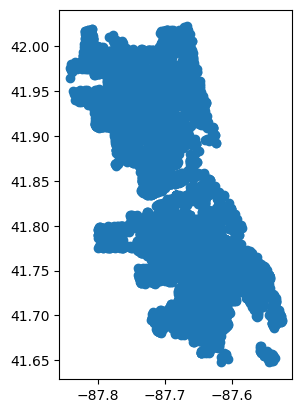

In [198]:
step7 = step7.set_crs(4326)
step7 = step7.to_crs(4326)
step7.plot()

In [199]:
# spatial join
step7 = gpd.sjoin(step7, tracts_map, predicate="within", how='left')

In [200]:
len(step7)

12652

In [201]:
step7.to_csv('step7_manual_2.csv')

3 Addresses that didn't successfully spatially join that I needed to look up manually: 5042 S LARAMIE (on street city border): 17031560300 in Garfield Ridge, 5630 N OSAGE AVE: Norwood Park, 17031810400 5657 N FAIRVIEW AVE: Norwood Park, 17031810400

In [202]:
step7_manual = pd.read_csv('step7_manual_2.csv')
step7_manual.drop('Unnamed: 0', axis=1, inplace=True)
step7_manual.tail(2)

,LSLR Program,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,BOTH AS REQUIRED or Consumer,completed_year,...,m_is_intersection,_merge,geocoded lat,geocoded lon,geometry,index_right,GEOID,NAME,Community Area,CA
12650,Homeowner Initiated LSLR,BOTH AS REQUIRED,217 S Bell Ave,Completed,60612,27.0,2021-06-15 00:00:00,Homeowner Initiated,NaN,2021,...,False,both,NaN,NaN,POINT (-87.682664156211 41.878518344119),734.0,17031838000,8380.0,Near West Side,28
12651,Homeowner Initiated LSLR,BOTH AS REQUIRED,1215 W Cornelia Ave,Completed,60657,44.0,2021-05-14 00:00:00,Homeowner Initiated,NaN,2021,...,False,both,NaN,NaN,POINT (-87.659518596909 41.945257237256),206.0,17031061500,615.0,Lake View,6


## Clean up and export

In [177]:
step7_manual.columns

Index(['LSLR Program', 'Public or Consumer', 'Work Address', 'Status', 'Zip',
       'Ward', 'Date Completed', 'program', 'BOTH AS REQUIRED or Consumer',
       'completed_year', 'completed_month_year', 'completed_day',
       'clean_address', 'id', 'program_clean_address', 'full_address', 'row',
       'classification_for_entire_service_line', 'stnum1', 'stnum2', 'stdir',
       'stname', 'sttype', 'zip', 'geocoder', 'lat', 'long', 'geoid',
       'matched_address', 'm_is_intersection', '_merge', 'geocoded lat',
       'geocoded lon', 'geometry', 'index_right', 'GEOID', 'NAME',
       'Community Area'],
      dtype='object')

In [203]:
step8 = step7_manual.drop(['LSLR Program', 'BOTH AS REQUIRED or Consumer', 'id', 'geocoded lat', 'geocoded lon', 'index_right'], axis=1)

In [204]:
# add full completed days
step8['Date Completed'] = pd.to_datetime(step8['Date Completed'])
step8['completed_day_full'] = step8['Date Completed'].dt.strftime('%Y-%m-%d')
#programs['completed_day'] = programs['Date Completed'].dt.strftime('%m-%d')

In [205]:
step8.head()

,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,completed_year,completed_month_year,completed_day,...,geoid,matched_address,m_is_intersection,_merge,geometry,GEOID,NAME,Community Area,CA,completed_day_full
0,PUBLIC,11014 S AVENUE H,Completed,60617,10.0,2025-08-25 15:00:00,Breaks Leaks,2025,08/2025,08-25,...,NaN,NaN,NaN,left_only,POINT (-87.532946029631 41.695162818406),17031520500,5205.00,East Side,52,2025-08-25
1,BOTH AS REQUIRED,1127 W Wolfram,Completed,60657,44.0,2025-08-22 17:09:00,Homeowner Initiated,2025,08/2025,08-22,...,NaN,NaN,NaN,left_only,POINT (-87.657363092128 41.933434330781),17031062900,629.00,Lake View,6,2025-08-22
2,CONSUMER,35 37 W 113TH ST,Completed,60628,9.0,2025-08-11 00:00:00,Block Level LSLR,2025,08/2025,08-11,...,NaN,NaN,NaN,left_only,POINT (-87.624322088096 41.688880284153),17031491300,4913.00,Roseland,49,2025-08-11
3,CONSUMER,3650 N NOTTINGHAM AVE,Completed,60634,38.0,2025-08-04 16:56:00,Breaks Leaks,2025,08/2025,08-04,...,NaN,NaN,NaN,left_only,POINT (-87.804657092815 41.946235762097),17031170300,1703.00,Dunning,17,2025-08-04
4,BOTH AS REQUIRED,2221 W. WIINNEMAC,Completed,60625,40.0,2025-07-30 00:00:00,Homeowner Initiated,2025,07/2025,07-30,...,NaN,NaN,NaN,left_only,POINT (-87.685162110066 41.973043813187),17031040401,404.01,Lincoln Square,4,2025-07-30


In [206]:
step8.to_csv('../processed/replacements_cleaned_updated.csv', index=False)